In [ ]:
# View and modify the working path
import os
from google.colab import drive

# View current working directory
print("Current Working Directory:", os.getcwd())

# Mount Google Drive
drive.mount('/content/gdrive')

# Change working directory to your file position
path = "/content/gdrive/My Drive/BD4H/data"
os.chdir(path)

# Confirm the change
print("Working Directory:", os.getcwd())

Current Working Directory: /content
Mounted at /content/gdrive
Working Directory: /content/gdrive/My Drive/BD4H/data


In [ ]:
# Initialize ChatOpenAI
################################ This need to be removed ##################################################
os.environ["OPENAI_API_KEY"] = 'xxxxxxxxxxxxx'
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

# llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
import pandas as pd

readmission_positive = pd.read_csv('/content/gdrive/My Drive/BD4H/data/readmission_positive.csv')
readmission_negative = pd.read_csv('/content/gdrive/My Drive/BD4H/data/readmission_negative.csv')
readmission_30d_positive = pd.read_csv('/content/gdrive/My Drive/BD4H/data/readmission_30d_positive.csv')
readmission_30d_negative = pd.read_csv('/content/gdrive/My Drive/BD4H/data/readmission_30d_negative.csv')

# pd.set_option('display.max_colwidth', None)
print(readmission_positive.shape, readmission_negative.shape)
display(readmission_positive.head(3))
display(readmission_negative.head(3))
print('\n')
print(readmission_30d_positive.shape, readmission_30d_negative.shape)
display(readmission_30d_positive.head(3))
display(readmission_30d_negative.head(3))

(3544, 3) (3544, 3)


,HADM_ID,cleaned_text,gen_readm
0,100018.0,Admission Date: [**--**] Discharge Date: [**--...,positive
1,100020.0,Admission Date: [**--**] Discharge Date: [**--...,positive
2,100039.0,Admission Date: [**--**] Discharge Date: [**--...,positive


,HADM_ID,cleaned_text,gen_readm
0,165403.0,Admission Date: [**--**] Discharge Date: [**--...,negative
1,155222.0,Admission Date: [**--**] Discharge Date: [**--...,negative
2,162999.0,Admission Date: [**--**] Discharge Date: [**--...,negative




(963, 3) (963, 3)


,HADM_ID,cleaned_text,readm_30d
0,100020.0,Admission Date: [**--**] Discharge Date: [**--...,positive
1,100039.0,Admission Date: [**--**] Discharge Date: [**--...,positive
2,100120.0,Admission Date: [**--**] Discharge Date: [**--...,positive


,HADM_ID,cleaned_text,readm_30d
0,195991.0,Admission Date: [**--**] Discharge Date: [**--...,negative
1,192808.0,Admission Date: [**--**] Discharge Date: [**--...,negative
2,133926.0,Admission Date: [**--**] Discharge Date: [**--...,negative


## Use Langchain to do the prediciton
### Initial test

In [ ]:
%%capture
!pip install langchain openai langchain_community langchain_openai

In [ ]:
import pandas as pd
from langchain.prompts import FewShotPromptTemplate, PromptTemplate
from langchain.chains import LLMChain
from langchain_openai import ChatOpenAI

In [ ]:
# Create readmission training and test sets
readmission_positive_train = readmission_positive.sample(3)
readmission_positive_test = readmission_positive.sample(5)

readmission_negative_train = readmission_negative.sample(3)
readmission_negative_test = readmission_negative.sample(5)

readmission_train = pd.concat([readmission_positive_train, readmission_negative_train])
readmission_test = pd.concat([readmission_positive_test, readmission_negative_test])


# Create readmission-30d training and test sets
readmission_30d_positive_train = readmission_30d_positive.sample(3)
readmission_30d_positive_test = readmission_30d_positive.sample(5)

readmission_30d_negative_train = readmission_30d_negative.sample(3)
readmission_30d_negative_test = readmission_30d_negative.sample(5)

readmission_30d_train = pd.concat([readmission_30d_positive_train, readmission_30d_negative_train])
readmission_30d_test = pd.concat([readmission_30d_positive_test, readmission_30d_negative_test])

print(readmission_train.shape, readmission_test.shape)
print(readmission_30d_train.shape, readmission_30d_test.shape)


(6, 3) (10, 3)
(6, 3) (10, 3)


In [ ]:
# Relabel df for LLM to better understand, with low likelyhood of misunderstanding
readmission_train['readmission_signal'] = readmission_train['gen_readm'].apply(lambda x: 'readmission' if x == 'positive' else 'no_readmission')
readmission_test['readmission_signal'] = readmission_test['gen_readm'].apply(lambda x: 'readmission' if x == 'positive' else 'no_readmission')

readmission_30d_train['readmission_30d_signal'] = readmission_30d_train['readm_30d'].apply(lambda x: 'readmission' if x == 'positive' else 'no_readmission')
readmission_30d_test['readmission_30d_signal'] = readmission_30d_test['readm_30d'].apply(lambda x: 'readmission' if x == 'positive' else 'no_readmission')

display(readmission_train.shape, readmission_train.head(1))
display(readmission_test.shape, readmission_test.head(1))
display(readmission_30d_train.shape, readmission_30d_train.head(1))
display(readmission_30d_test.shape, readmission_30d_test.head(1))

(6, 4)

,HADM_ID,cleaned_text,gen_readm,readmission_signal
38,101072.0,Admission Date: [**--**] Discharge Date: [**--...,positive,readmission


(10, 4)

,HADM_ID,cleaned_text,gen_readm,readmission_signal
3391,196064.0,Admission Date: [**--**] Discharge Date: [**--...,positive,readmission


(6, 4)

,HADM_ID,cleaned_text,readm_30d,readmission_30d_signal
601,164133.0,Admission Date: [**--**] Discharge Date: [**--...,positive,readmission


(10, 4)

,HADM_ID,cleaned_text,readm_30d,readmission_30d_signal
104,108877.0,Admission Date: [**--**] Discharge Date: [**--...,positive,readmission


In [ ]:
# Initialize the OpenAI GPT-4 mini model with LangChain
llm = ChatOpenAI(model_name="gpt-4o-mini")

print(readmission_train.shape, readmission_test.shape)
print(readmission_30d_train.shape, readmission_30d_test.shape)

# Convert DataFrame rows to few-shot examples
few_shot_examples_readmission = [
    {"clinical_notes": row["cleaned_text"], "prediction": row["readmission_signal"]}
    for _, row in readmission_train.iterrows()
]

few_shot_examples_readmission_30d = [
    {"clinical_notes": row["cleaned_text"], "prediction": row["readmission_30d_signal"]}
    for _, row in readmission_30d_train.iterrows()
]

# Format examples for the prompt
formatted_examples_readmission = "\n".join([
    f"Clinical Notes: {ex['clinical_notes']}\nPrediction: {ex['prediction']}"
    for ex in few_shot_examples_readmission
])

formatted_examples_readmission_30d = "\n".join([
    f"Clinical Notes: {ex['clinical_notes']}\nPrediction: {ex['prediction']}"
    for ex in few_shot_examples_readmission_30d
])

(6, 4) (10, 4)
(6, 4) (10, 4)


In [ ]:
# Define a template for each example (one-shot format within few-shot structure)
example_prompt = PromptTemplate(
    input_variables=["clinical_notes", "prediction"],
    template="Clinical Notes: {clinical_notes}\nPrediction: {prediction}\n"
)

# Define prefix and suffix for FewShotPromptTemplate
prefix = """
You are a professional doctor. Given the clinical notes, predict if the patient will be readmitted.

# Examples:
# - For a patient with stable vitals and no major risk factors, the reasoning should reflect unlikely readmission.
# - For a patient with significant health risk history and recent health complications, the reasoning might indicate a higher likelihood of readmission.
"""

suffix = """
For each clinical note, follow these steps:
1. **Chain of Thought**: Analyze the clinical notes in a balanced, neutral way. Consider patient history, symptoms, any recent treatments, and both supporting and discouraging factors for readmission.
2. **ReAct**: Reflect actively on each part of your thought process, carefully identifying factors that may support readmission.
3. **Final Review**: Re-examine all factors to ensure both positive and negative indicators were considered. Confirm the final prediction only after ensuring a balanced perspective.
4. **Final Prediction**: Based on your balanced reasoning and reflection, provide a final prediction on the likelihood of readmission being postive or negative.

Clinical Notes: {clinical_notes}
Thought Process (Chain of Thought, ReAct, Final Review, and Final Prediction):
"""


# Define the FewShotPromptTemplate using the example prompt, prefix, and suffix
prompt = FewShotPromptTemplate(
    examples=few_shot_examples_readmission,
    example_prompt=example_prompt,
    prefix=prefix,
    suffix=suffix,
    input_variables=["clinical_notes"]
)

# Create an LLMChain for predictions with chain of thought and ReAct reasoning
chain_of_thought_chain = LLMChain(llm=llm, prompt=prompt)

# Function to predict readmission with CoT and ReAct reasoning
def predict_with_cot_react_reasoning(clinical_notes):
    prediction = chain_of_thought_chain.invoke({"clinical_notes": clinical_notes, "examples": formatted_examples_readmission})
    return prediction


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


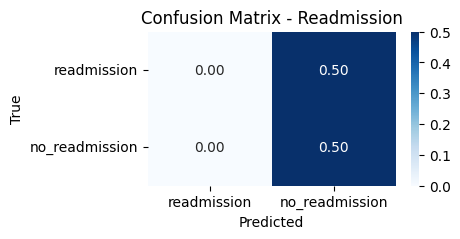



      Metric     Value
0   Accuracy  0.500000
1  Precision  0.250000
2     Recall  0.500000
3   F1 Score  0.333333


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Function to make predictions on test data and calculate metrics
def evaluate_langchain(test_data):
    true_labels = test_data["readmission_signal"].to_list()
    predictions = []

    for clinical_notes in test_data["cleaned_text"]:
        # Generate prediction using the LangChain pipeline with CoT and ReAct reasoning
        prediction = predict_with_cot_react_reasoning(clinical_notes)

        # Extract the final prediction from the model response
        if "readmission" in prediction:
            predictions.append("readmission")
        else:
            predictions.append("no_readmission")

    true_labels = readmission_test["readmission_signal"].to_list()

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions,average='macro')
    recall = recall_score(true_labels, predictions,average='weighted')
    f1 = f1_score(true_labels, predictions,average='weighted')
    conf_matrix = confusion_matrix(true_labels, predictions, labels= ['readmission', 'no_readmission'])
    conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

    # Create a heatmap
    plt.figure(figsize=(4, 2))
    sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=['readmission', 'no_readmission'], yticklabels=['readmission', 'no_readmission'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Readmission')
    plt.show()
    print('\n')

    # Create a DataFrame to store metrics
    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Value": [accuracy, precision, recall, f1]
    })

    print(metrics_df)

evaluate_langchain(readmission_test)

# Combine LLM with Scikit-Learn for Classification




In [ ]:
%%capture
%pip install scikit-llm

100%|██████████| 10/10 [00:39<00:00,  4.00s/it]


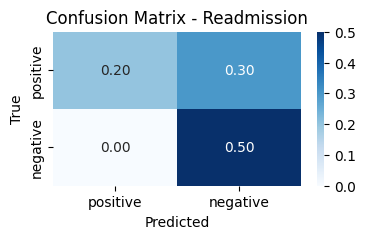

,Metric,Value
0,Accuracy,0.700000
1,Precision,0.625000
2,Recall,1.000000
3,F1 Score,0.769231


In [ ]:
from skllm.models.gpt.classification.few_shot import FewShotGPTClassifier

cl = FewShotGPTClassifier(model="gpt-4o-mini", key=OPENAI_API_KEY)

# adding training samples
X_train = readmission_train["cleaned_text"]
y_train = readmission_train["readmission_signal"]
cl.fit(X_train.values, y_train.values)

# predict on test data
X_test = readmission_test["cleaned_text"]
y_test = readmission_test["readmission_signal"]
y_pred = cl.predict(X_test.values)

# Calcualte metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label= 'readmission')
recall = recall_score(y_test, y_pred, pos_label = 'readmission')
f1 = f1_score(y_test, y_pred, pos_label= 'readmission')
conf_matrix = confusion_matrix(y_test, y_pred, labels = ['no_readmission', 'readmission'] )
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Readmission')
plt.show()
print('\n')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

display(metrics_df)

100%|██████████| 10/10 [00:39<00:00,  3.96s/it]


Confusion Matrix: 
 [[2 3]
 [0 5]]


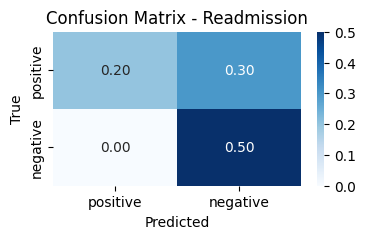

,Metric,Value
0,Accuracy,0.700000
1,Precision,0.625000
2,Recall,1.000000
3,F1 Score,0.769231


In [ ]:
from skllm.models.gpt.classification.zero_shot import CoTGPTClassifier

clf = CoTGPTClassifier(model="gpt-4o-mini", key=OPENAI_API_KEY)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_pred_label = [row[0] for row in y_pred]
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_label))

accuracy = accuracy_score(y_test, y_pred_label)
precision = precision_score(y_test, y_pred_label, pos_label= 'readmission')
recall = recall_score(y_test, y_pred_label, pos_label = 'readmission')
f1 = f1_score(y_test, y_pred_label, pos_label= 'readmission')
conf_matrix = confusion_matrix(y_test, y_pred_label, labels = ['no_readmission', 'readmission'] )
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Readmission')
plt.show()
print('\n')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

display(metrics_df)

100%|██████████| 10/10 [00:26<00:00,  2.60s/it]


Confusion Matrix: 
 [[5 0]
 [4 1]]


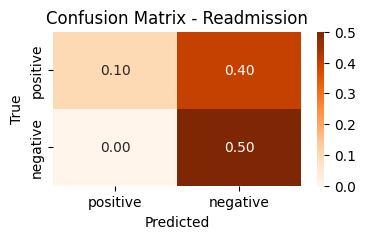

,Metric,Value
0,Accuracy,0.600000
1,Precision,1.000000
2,Recall,0.200000
3,F1 Score,0.333333


In [ ]:
# Few shot for readmission-30d
cl = FewShotGPTClassifier(model="gpt-4o-mini", key=OPENAI_API_KEY)

X_train = readmission_30d_train["cleaned_text"]
y_train = readmission_30d_train["readmission_30d_signal"]
cl.fit(X_train.values, y_train.values)

# predict on test data
X_test = readmission_30d_test["cleaned_text"]
y_test = readmission_30d_test["readmission_30d_signal"]
y_pred = cl.predict(X_test.values)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

# Calcualte metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label= 'readmission')
recall = recall_score(y_test, y_pred, pos_label = 'readmission')
f1 = f1_score(y_test, y_pred, pos_label= 'readmission')
conf_matrix = confusion_matrix(y_test, y_pred, labels = ['readmission', 'no_readmission'] )
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Oranges', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Readmission')
plt.show()
print('\n')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

display(metrics_df)

100%|██████████| 10/10 [00:36<00:00,  3.65s/it]


Confusion Matrix: 
 [[1 4]
 [0 5]]


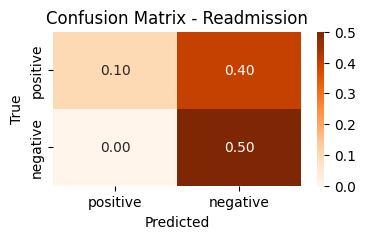

,Metric,Value
0,Accuracy,0.600000
1,Precision,0.555556
2,Recall,1.000000
3,F1 Score,0.714286


In [ ]:
clf = CoTGPTClassifier(model="gpt-4o-mini", key=OPENAI_API_KEY)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_pred_label = [row[0] for row in y_pred]
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_label))

accuracy = accuracy_score(y_test, y_pred_label)
precision = precision_score(y_test, y_pred_label, pos_label= 'readmission')
recall = recall_score(y_test, y_pred_label, pos_label = 'readmission')
f1 = f1_score(y_test, y_pred_label, pos_label= 'readmission')
conf_matrix = confusion_matrix(y_test, y_pred_label, labels = ['no_readmission', 'readmission'] )
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Oranges', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Readmission')
plt.show()
print('\n')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

display(metrics_df)